In [0]:
# =============================================================================
# Phase 4.4 — FTTransformer Flight Delay Prediction
# =============================================================================
#
# CLUSTER USAGE:
#   Sections 0–2  → Team_1_2  (CPU/Spark)
#   Sections 3–11 → GPU cluster (NVIDIA A10G, 23.7GB VRAM)
#
# INPUTS (from Phase 4.3 / undersampled pipeline):
#   df_train_phase3_downsampled.parquet  (14.5M rows, 197 cols, 3:1 class ratio)
#   df_val_phase3.parquet                (6.3M rows, 197 cols, full)
#   df_test_phase3.parquet               (6.2M rows, 197 cols, full)
#
# OUTPUTS:
#   df_train_gpu_kenzie.parquet   — GPU-ready train (USE_COLS only)
#   df_val_gpu_kenzie.parquet
#   df_test_gpu_kenzie.parquet
#   use_cols_final.json           — ordered feature list
#   scaling_stats_44.json         — residual scaling stats
#   ft_transformer_best.pt        — best model checkpoint
#   best_hparams.json             — Optuna winning params
#   threshold_final.json          — frozen classification threshold
#   shap_summary.csv              — mean absolute SHAP per feature
#
# KEY FACTS:
#   - Undersampling used instead of class_weight — no w tensor needed
#   - Train class ratio ~3:1 (on-time:delayed) after undersampling
#   - Graph cols populated correctly: origin/dest pagerank + betweenness
#   - inbound_delay_flag: still all zeros (Phase 4.2 cascade issue) — excluded
#   - 50 residual columns scaled in Section 1b
#   - Primary metric: F-beta (beta=2.0) — team requirement
#   - Early stopping monitors val F-beta
#   - batch_size=4096, num_workers=8 for A10G 23.7GB / 16 cores
# =============================================================================

In [0]:
# Just confirm everything works now

# 0. Setup

## Imports

In [0]:
import json
import numpy as np
import pandas as pd
 
# Spark — Team_1_2 only
try:
    import pyspark.sql.functions as F
    from pyspark.ml.feature import VectorAssembler
    from pyspark.ml.stat import Correlation
    SPARK_AVAILABLE = True
except ImportError:
    SPARK_AVAILABLE = False
    print("PySpark not available — Sections 1-2 skipped")
 
# PyTorch
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import DataLoader, TensorDataset
    TORCH_AVAILABLE = True
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"PyTorch {torch.__version__} | device: {DEVICE}")
    if DEVICE == "cuda":
        props = torch.cuda.get_device_properties(0)
        print(f"GPU: {props.name} | VRAM: {props.total_memory/1e9:.1f} GB")
except ImportError:
    TORCH_AVAILABLE = False
    DEVICE = "cpu"
    print("PyTorch not available")
 
# Optuna
try:
    import optuna
    from optuna.samplers import TPESampler
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    OPTUNA_AVAILABLE = True
    print(f"Optuna {optuna.__version__}")
except ImportError:
    OPTUNA_AVAILABLE = False
    print("Optuna not available — pip install optuna")
 
# SHAP
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print("SHAP not available — pip install shap")
 
# sklearn
from sklearn.metrics import (
    f1_score, fbeta_score, average_precision_score,
    roc_auc_score, confusion_matrix, accuracy_score,
)

PyTorch 2.7.0+cu126 | device: cuda
GPU: Tesla T4 | VRAM: 15.7 GB
Optuna 3.6.1


## Paths

In [0]:
BASE_GROUP = "dbfs:/student-groups/Group_01_02"
LOCAL_BASE = "/dbfs/student-groups/Group_01_02"
TARGET     = "DEP_DEL15"
 
# Inputs — undersampled train, full val/test
TRAIN_PATH = f"{BASE_GROUP}/df_train_phase3_downsampled.parquet"
VAL_PATH   = f"{BASE_GROUP}/df_val_phase3.parquet"
TEST_PATH  = f"{BASE_GROUP}/df_test_phase3.parquet"
 
# GPU-ready outputs — written by Section 2f, read by Section 5
GPU_TRAIN  = f"{LOCAL_BASE}/df_train_gpu_kenzie.parquet"
GPU_VAL    = f"{LOCAL_BASE}/df_val_gpu_kenzie.parquet"
GPU_TEST   = f"{LOCAL_BASE}/df_test_gpu_kenzie.parquet"
 
CHECKPOINT_PATH = f"{LOCAL_BASE}/ft_transformer_best.pt"

## Config Dict

In [0]:
CONFIG = {
    # Hardware (A10G 23.7GB, 16 logical cores confirmed)
    "batch_size":         4096,
    "num_workers":        8,
 
    # Training
    "n_epochs":           30,
    "patience":           7,
    "grad_clip":          1.0,
    "warmup_frac":        0.05,
 
    # Starting architecture (overridden by Optuna)
    "d_model":            64,
    "n_heads":            8,
    "n_layers":           3,
    "ffn_factor":         4,
    "dropout":            0.2,
    "attn_dropout":       0.1,
 
    # Starting optimiser
    "lr":                 1e-4,
    "weight_decay":       1e-4,
 
    # Optuna
    "n_trials":           40,
    "trial_epochs":       15,
    "trial_patience":     5,
    "retrain_epochs":     50,
    "retrain_patience":   10,
 
    # Threshold — F-beta with beta=2 (recall-weighted, team requirement)
    # beta=2: missing a delay is 2x worse than a false alarm
    "threshold_metric":   "fbeta",
    "threshold_step":     0.01,
    "beta":               2.0,
 
    # SHAP
    "shap_n_background":  5000,
    "shap_n_explain":     5000,
    "shap_seed":          42,
}

## Unused Columns

In [0]:
EXTRA_EXCLUDE = {
    TARGET,
    "crs_dep_minutes", "dep_2h_bin", "_sort_date", "fl_date_d",
    "TAIL_NUM", "FL_DATE", "ROUTE", "dep_time_blk", "flight_date",
    "crs_dep_timestamp", "prediction_time",
    "weather_window_start", "weather_window_end",
    "closest_station_1", "closest_station_2", "closest_station_3",
    "closest_station_4", "closest_station_5",
    "last_feat_pressure_category", "last_feat_pressure_tendency_category",
    "last_feat_visibility_category", "last_feat_ceiling_category",
    "avg_feat_ceiling_hundreds_ft",
    "CRS_ARR_TIME",
    "DEST_AIRPORT_ID", "DEST_AIRPORT_SEQ_ID", "DEST_CITY_MARKET_ID",
    "DEST_STATE_FIPS", "DEST_WAC",
    "ORIGIN_AIRPORT_ID", "ORIGIN_AIRPORT_SEQ_ID", "ORIGIN_CITY_MARKET_ID",
    "ORIGIN_STATE_FIPS", "ORIGIN_WAC",
    "OP_CARRIER_AIRLINE_ID", "OP_CARRIER_FL_NUM",
    "DISTANCE_GROUP",
}
 
STRING_LIKE = ("string", "date", "timestamp")
_NUM_LIKE   = ("double", "int", "bigint", "float", "decimal")

# 1. Data Prep

## Read in data

In [0]:
df_train = spark.read.parquet(TRAIN_PATH)
df_val   = spark.read.parquet(VAL_PATH)
df_test  = spark.read.parquet(TEST_PATH)
 
print(f"[1a] Train: {df_train.count():,} x {len(df_train.columns)} cols")
print(f"     Val:   {df_val.count():,} | Test: {df_test.count():,}")
 
# Verify graph columns populated correctly (fixed in Phase 4.2)
_graph_check = [
    "origin_pagerank", "origin_betweenness",
    "dest_pagerank", "dest_betweenness", "inbound_delay_flag",
]
_present = [c for c in _graph_check if c in df_train.columns]
if _present:
    _null_row = df_train.agg(
        *[F.sum(F.col(c).isNull().cast("int")).alias(c) for c in _present]
    ).collect()[0]
    for c in _present:
        n = _null_row[c]
        status = "✓" if n == 0 else f"WARNING {n:,} nulls"
        print(f"[1a] {c}: {status}")

[1a] Train: 14,515,569 x 199 cols
     Val:   6,329,538 | Test: 6,241,008
[1a] origin_pagerank: ✓
[1a] origin_betweenness: ✓
[1a] dest_pagerank: ✓
[1a] dest_betweenness: ✓
[1a] inbound_delay_flag: ✓


## Scale columns that haven't been scaled yet

In [0]:
    COLS_TO_SCALE = [
        "busy_origin_x_peak_wx", "carrier_delay_rate", "carrier_x_origin_delay",
        "dest_delay_rate", "dest_train_departures", "dest_betweenness",
        "dest_pagerank", "distance_x_route_delay",
        "evening_peak_x_route_delay", "evening_peak_x_wx_rh_precip",
        "holiday_adj_x_2h_deps", "holiday_x_route_delay", "hour_delay_rate",
        "hour_month_cross_1", "hour_month_cross_2", "hub_dest_x_dest_delay",
        "hub_dest_x_route_delay", "hub_origin_x_carrier_delay", "hub_origin_x_prev2h",
        "late_night_x_carrier_delay", "late_night_x_vis_bin", "month_cos_x_wind_bin",
        "month_sin_x_distance", "morning_peak_x_origin_delay", "morning_x_wx_rh_precip",
        "od_distinct_x_hour_delay", "origin_2h_sched_departures", "origin_betweenness",
        "origin_delay_rate", "origin_dest_distinct_count", "origin_pagerank",
        "origin_pressure_index", "origin_sched_count_prev2h",
        "origin_train_departures", "peak_wind_x_vis_bin", "post_holiday_x_dest_delay",
        "pre_holiday_x_origin_delay", "precip_bin", "precip_bin_x_wind_bin",
        "quarter_cos_x_route_delay", "route_carrier_residual", "route_delay_rate",
        "severe_wx_index", "temp_anomaly_station_month", "vis_bin",
        "vis_bin_x_wx_wind_precip", "weekend_x_evening_peak", "weekend_x_route_delay",
        "wind_bin", "wx_evening_x_bad_vis", "wx_peak_x_strong_wind",
        "wx_rh_x_precip", "wx_vis_x_wind", "wx_wind_x_precip",
    ]
 
    # Only scale columns that actually exist in the parquet
    COLS_TO_SCALE = [c for c in COLS_TO_SCALE if c in df_train.columns]
    print(f"[1b] Scaling {len(COLS_TO_SCALE)} residual columns")
 
    # Single Spark action — all mins and maxes on train only
    _mm = df_train.select(
        *[F.min(c).alias(f"{c}__min") for c in COLS_TO_SCALE] +
         [F.max(c).alias(f"{c}__max") for c in COLS_TO_SCALE]
    ).collect()[0]
 
    _scale_stats = {}
    for c in COLS_TO_SCALE:
        mn   = float(_mm[f"{c}__min"] or 0.0)
        mx   = float(_mm[f"{c}__max"] or mn)
        span = (mx - mn) if (mx - mn) > 1e-12 else 1.0
        _scale_stats[c] = (mn, span)
 
    def _apply_scale(dfx):
        out = dfx
        for c, (mn, span) in _scale_stats.items():
            out = out.withColumn(
                f"{c}_scl",
                (F.col(c).cast("double") - F.lit(mn)) / F.lit(span)
            )
        return out
 
    df_train = _apply_scale(df_train)
    df_val   = _apply_scale(df_val)
    df_test  = _apply_scale(df_test)
    print(f"[1b] Scaling applied ✓")
 
    # Save scaling stats
    dbutils.fs.put(
        f"{BASE_GROUP}/scaling_stats_44.json",
        json.dumps({c: {"min": mn, "span": sp}
                    for c, (mn, sp) in _scale_stats.items()}),
        overwrite=True
    )
 
    # ── 1c. Drop raw cols where _scl exists ───────────────────────────────────
 
    _drop = [
        c for c in df_train.columns
        if c + "_scl" in set(df_train.columns)
        and c not in EXTRA_EXCLUDE
        and c != TARGET
    ]
    df_train = df_train.drop(*_drop)
    df_val   = df_val.drop(*_drop)
    df_test  = df_test.drop(*_drop)
    print(f"[1c] Dropped {len(_drop)} raw cols | schema: {len(df_train.columns)} cols")

[1b] Scaling 54 residual columns
[1b] Scaling applied ✓
Wrote 3333 bytes.
[1c] Dropped 60 raw cols | schema: 193 cols


## Check for NULLs

In [0]:
prelim_candidates = [
    name for name, dtype in df_train.dtypes
    if name not in EXTRA_EXCLUDE
    and name != TARGET
    and not any(dtype.startswith(t) for t in STRING_LIKE)
]
def null_audit(df, split_name, cols):
    row = df.agg(
        *[F.sum(F.col(c).isNull().cast("int")).alias(c)
          for c in cols if c in df.columns]
    ).collect()[0]
    bad = [(c, row[c]) for c in cols if c in df.columns and row[c] > 0]
    if bad:
        print(f"[1d] {split_name}: {len(bad)} cols with nulls — FIX BEFORE TRAINING")
        for c, n in bad:
            print(f"     {c}: {n:,}")
    else:
        print(f"[1d] {split_name}: all {len(cols)} cols null-free ✓")
null_audit(df_train, "TRAIN", prelim_candidates)
null_audit(df_val,   "VAL",   prelim_candidates)
null_audit(df_test,  "TEST",  prelim_candidates)

[1d] TRAIN: all 145 cols null-free ✓
[1d] VAL: all 145 cols null-free ✓
[1d] TEST: all 145 cols null-free ✓


## Check for leakage

In [0]:
TARGET_ENC_COLS = {
    "OP_UNIQUE_CARRIER": "carrier_delay_rate_scl",
    "ORIGIN":            "origin_delay_rate_scl",
    "DEST":              "dest_delay_rate_scl",
    "dep_hour":          "hour_delay_rate_scl",
}
print("[1e] Leakage audit:")
for grp, enc in TARGET_ENC_COLS.items():
    if enc not in df_val.columns:
        print(f"     {enc}: not in df_val — skip")
        continue
    emp = df_val.filter(F.col(TARGET).isNotNull()).groupBy(grp).agg(
        F.mean(TARGET).alias("emp")
    )
    s = (
        df_val.select(grp, enc).distinct()
        .join(emp, on=grp, how="left")
        .withColumn("diff", F.abs(F.col(enc) - F.col("emp")))
        .agg(F.mean("diff").alias("md"),
             F.sum((F.col("diff") < F.lit(1e-6)).cast("int")).alias("identical"),
             F.count("*").alias("total"))
        .collect()[0]
    )
    status = "WARNING" if s["identical"] == s["total"] else "OK"
    print(f"     {enc}: mean_diff={s['md']:.5f} | {status}")
 

[1e] Leakage audit:
     carrier_delay_rate_scl: mean_diff=0.44532 | OK
     origin_delay_rate_scl: mean_diff=0.02336 | OK
     dest_delay_rate_scl: mean_diff=0.15966 | OK
     hour_delay_rate_scl: mean_diff=0.46030 | OK


# 2. Basic Feature Selection

In [0]:
if not SPARK_AVAILABLE:
    print("[2] Skipping — run on Team_1_2")
else:
 
    # ── 2a. Variance filter ───────────────────────────────────────────────────
 
    STD_THRESHOLD = 0.01
    std_row = df_train.select(
        *[F.stddev(F.col(c)).alias(c)
          for c in prelim_candidates if c in df_train.columns]
    ).collect()[0]
 
    low_var_cols = [
        c for c in prelim_candidates
        if c in df_train.columns and float(std_row[c] or 0.0) < STD_THRESHOLD
    ]
    print(f"[2a] Low variance (std < {STD_THRESHOLD}): {len(low_var_cols)}")
    print(f"     {low_var_cols}")
    # To rescue: low_var_cols.remove('col_name')
 
    # ── 2b. Pearson correlation filter ────────────────────────────────────────
 
    PEARSON_THRESHOLD = 0.005
    sample_cols = [c for c in prelim_candidates if c in df_train.columns]
    sample_df = (
        df_train.filter(F.col(TARGET).isin(0, 1))
        .select(*sample_cols, TARGET)
        .sample(False, 0.005, seed=42)
    )
    vec_df = VectorAssembler(
        inputCols=sample_cols + [TARGET], outputCol="_vec", handleInvalid="skip"
    ).transform(sample_df)
    corr_mat = Correlation.corr(vec_df, "_vec", method="pearson").head()[0].toArray()
    ti = len(sample_cols)
    corr_pd = (
        pd.DataFrame(
            [(sample_cols[i], float(corr_mat[i, ti])) for i in range(ti)],
            columns=["feature", "pearson_r"]
        )
        .assign(abs_r=lambda x: x["pearson_r"].abs())
        .sort_values("abs_r", ascending=False)
    )
    low_corr_cols = corr_pd[corr_pd["abs_r"] < PEARSON_THRESHOLD]["feature"].tolist()
    print(f"[2b] Low Pearson |r| < {PEARSON_THRESHOLD}: {len(low_corr_cols)} cols")
    print(f"\n     Top 20 by |r|:")
    print(corr_pd.head(20).to_string(index=False))
    # To rescue: low_corr_cols.remove('col_name')
 
    # ── 2c. Redundancy filter ─────────────────────────────────────────────────
 
    REDUNDANCY_THRESHOLD = 0.95
    sample_pd = (
        df_train.filter(F.col(TARGET).isin(0, 1))
        .select(*sample_cols)
        .sample(False, 0.005, seed=42)
        .toPandas()
    )
    pw = sample_pd.corr().abs()
    redundant_drops = set()
    ranked = corr_pd["feature"].tolist()
 
    for i, c1 in enumerate(ranked):
        if c1 in redundant_drops:
            continue
        for c2 in ranked[i+1:]:
            if c2 in redundant_drops:
                continue
            if c1 not in pw.columns or c2 not in pw.columns:
                continue
            if pw.loc[c1, c2] > REDUNDANCY_THRESHOLD:
                redundant_drops.add(c2)
 
    # Manual overrides from previous run review
    redundant_drops.discard('CRS_DEP_TIME_scl')  # raw time != hour_delay_rate encoding
    redundant_drops.discard('dep_hour_sin')       # cyclic encoding != target encoding
    redundant_drops.discard('DISTANCE_scl')       # continuous != bucketed DISTANCE_GROUP
 
    print(f"[2c] Redundant cols (after manual review): {len(redundant_drops)}")
    # To rescue: redundant_drops.discard('col_name')
 
    # ── 2d. Graph feature verification ───────────────────────────────────────
 
    GRAPH_COLS = [
        "origin_pagerank_scl", "dest_pagerank_scl",
        "origin_betweenness_scl", "dest_betweenness_scl",
        "inbound_delay_flag",
    ]
    print("[2d] Graph feature verification:")
    _gp = [c for c in GRAPH_COLS if c in df_train.columns]
    if _gp:
        _gs = df_train.select(
            *[F.min(c).alias(f"{c}_min") for c in _gp] +
             [F.max(c).alias(f"{c}_max") for c in _gp] +
             [F.stddev(c).alias(f"{c}_std") for c in _gp]
        ).collect()[0]
        for c in GRAPH_COLS:
            if c not in df_train.columns:
                print(f"     {c}: MISSING")
            else:
                s = float(_gs[f'{c}_std'] or 0)
                note = " (all zeros — excluded by variance filter)" if s < 0.001 else " ✓"
                print(f"     {c}: std={s:.5f}{note}")
 
    # ── 2e. Build USE_COLS ────────────────────────────────────────────────────
 
    cols_to_drop = EXTRA_EXCLUDE | set(low_var_cols) | set(low_corr_cols) | redundant_drops
 
    USE_COLS = sorted([
        name for name, dtype in df_train.dtypes
        if name not in cols_to_drop
        and name != TARGET
        and not any(dtype.startswith(t) for t in STRING_LIKE)
    ])
 
    print(f"[2e] Final USE_COLS: {len(USE_COLS)} features")
 
    dbutils.fs.put(
        f"{BASE_GROUP}/use_cols_final.json",
        json.dumps(USE_COLS),
        overwrite=True
    )
    print(f"[2e] USE_COLS saved ✓")
 
    # ── 2f. Write GPU-ready parquet splits ───────────────────────────────────
    # No class_weight — undersampling handles class imbalance
 
    keep_cols = [c for c in USE_COLS + [TARGET] if c in df_train.columns]
 
    df_train.select(keep_cols).repartition(512).write.mode("overwrite").parquet(
        f"{BASE_GROUP}/df_train_gpu_kenzie.parquet"
    )
    df_val.select(keep_cols).repartition(256).write.mode("overwrite").parquet(
        f"{BASE_GROUP}/df_val_gpu_kenzie.parquet"
    )
    df_test.select(keep_cols).repartition(256).write.mode("overwrite").parquet(
        f"{BASE_GROUP}/df_test_gpu_kenzie.parquet"
    )
    print(f"[2f] GPU-ready splits written ✓")
    print(f"     df_train_gpu_kenzie | df_val_gpu_kenzie | df_test_gpu_kenzie")

[2a] Low variance (std < 0.01): 8
     ['last_WeatherType_Hail', 'inbound_delay_flag', 'evening_peak_x_wx_rh_precip_scl', 'morning_x_wx_rh_precip_scl', 'origin_pressure_index_scl', 'vis_bin_x_wx_wind_precip_scl', 'wx_rh_x_precip_scl', 'wx_wind_x_precip_scl']
[2b] Low Pearson |r| < 0.005: 27 cols

     Top 20 by |r|:
                        feature  pearson_r    abs_r
            hour_delay_rate_scl   0.207740 0.207740
                   dep_hour_sin  -0.202400 0.202400
                   CRS_DEP_TIME   0.197666 0.197666
                       dep_hour   0.197503 0.197503
           route_delay_rate_scl   0.147270 0.147270
                is_morning_peak  -0.146955 0.146955
            route_delay_rate_7d   0.142363 0.142363
morning_peak_x_origin_delay_scl  -0.140474 0.140474
 evening_peak_x_route_delay_scl   0.139350 0.139350
   od_distinct_x_hour_delay_scl   0.126274 0.126274
                is_evening_peak   0.121971 0.121971
     carrier_x_origin_delay_scl   0.117691 0.117691
      

# 3. Threshold Sweep Utility

In [0]:
def sweep_threshold(y_true, y_prob, metric="fbeta", step=0.01, beta=2.0):
    """
    Sweep classification threshold 0.1→0.9 and return the value
    maximising the chosen metric.
 
    Args:
        metric : "fbeta" | "f1" | "precision" | "recall"
        beta   : F-beta weight (beta=2 → recall weighted 2x over precision)
 
    Returns dict: best_threshold, best_score, threshold_curve (DataFrame)
    """
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    records = []
    for t in np.arange(0.1, 0.9 + step, step):
        y_pred = (y_prob >= t).astype(int)
        tp = int(((y_pred == 1) & (y_true == 1)).sum())
        fp = int(((y_pred == 1) & (y_true == 0)).sum())
        fn = int(((y_pred == 0) & (y_true == 1)).sum())
        p  = tp / max(tp + fp, 1)
        r  = tp / max(tp + fn, 1)
        f1 = 2 * p * r / max(p + r, 1e-8)
        fb = (1 + beta**2) * p * r / max(beta**2 * p + r, 1e-8)
        records.append({"threshold": round(float(t), 3),
                         "precision": round(p, 5), "recall": round(r, 5),
                         "f1": round(f1, 5), "fbeta": round(fb, 5)})
    curve = pd.DataFrame(records)
    best  = curve.iloc[curve[metric].idxmax()]
    return {"best_threshold": best["threshold"],
            "best_score": best[metric],
            "threshold_curve": curve}
 
 
def print_threshold_report(result):
    print(f"Best threshold : {result['best_threshold']}")
    print(f"Best score     : {result['best_score']:.4f}")
    print("\nCurve (every 5th row):")
    print(result["threshold_curve"].iloc[::5].to_string(index=False))

In [0]:
# Unit test
np.random.seed(42)
_yt = np.random.choice([0, 1], 10_000, p=[0.75, 0.25])  # ~3:1 like undersampled train
_yp = np.where(_yt == 1, np.random.beta(5, 2, 10_000), np.random.beta(2, 5, 10_000))
_r  = sweep_threshold(_yt, _yp, metric="fbeta", beta=CONFIG["beta"])
assert _r["best_threshold"] < 0.5
print(f"[3] Threshold sweep ready ✓  "
      f"(unit test: best_threshold={_r['best_threshold']}, beta={CONFIG['beta']})")

[3] Threshold sweep ready ✓  (unit test: best_threshold=0.49, beta=2.0)


# 4. Transformer Architecture

In [0]:
if not TORCH_AVAILABLE:
  print("[4] Skipping — PyTorch not available")
else:
 
  class FeatureTokenizer(nn.Module):
      """
      Projects each scalar feature to a d_model-dimensional embedding.
          token_i = W_i * x_i + b_i
      W has shape [n_features, d_model] — one row per feature position.
      Column ordering must match use_cols_final.json consistently.
      """
      def __init__(self, n_features, d_model):
          super().__init__()
          self.W = nn.Parameter(torch.empty(n_features, d_model))
          self.b = nn.Parameter(torch.zeros(n_features, d_model))
          nn.init.kaiming_uniform_(self.W, a=np.sqrt(5))

      def forward(self, x):
          # x: [B, F] → [B, F, D]
          return x.unsqueeze(-1) * self.W.unsqueeze(0) + self.b.unsqueeze(0)


  class FTTransformer(nn.Module):
      """
      Feature Tokenization Transformer (Gorishniy et al. 2021)
      arxiv.org/abs/2106.11959

      Pipeline: tokenize → prepend CLS → N encoder layers → CLS head → logit
      No sigmoid — BCEWithLogitsLoss handles it numerically.
      Pre-norm (norm_first=True) for training stability.
      """
      def __init__(self, n_features, d_model=64, n_heads=8, n_layers=3,
                   d_ffn=256, dropout=0.2, attn_dropout=0.1):
          super().__init__()
          self.tokenizer = FeatureTokenizer(n_features, d_model)
          self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
          self.encoder   = nn.TransformerEncoder(
              nn.TransformerEncoderLayer(
                  d_model=d_model, nhead=n_heads, dim_feedforward=d_ffn,
                  dropout=dropout, activation="gelu",
                  batch_first=True, norm_first=True,
              ),
              num_layers=n_layers,
          )
          self.head = nn.Sequential(
              nn.LayerNorm(d_model),
              nn.Linear(d_model, d_model // 2),
              nn.GELU(),
              nn.Dropout(dropout),
              nn.Linear(d_model // 2, 1),
          )

      def forward(self, x):
          tokens = self.tokenizer(x)                          # [B, F, D]
          cls    = self.cls_token.expand(x.size(0), -1, -1)  # [B, 1, D]
          tokens = torch.cat([cls, tokens], dim=1)            # [B, F+1, D]
          enc    = self.encoder(tokens)                       # [B, F+1, D]
          return self.head(enc[:, 0, :]).squeeze(-1)          # [B]

      def n_params(self):
          return sum(p.numel() for p in self.parameters() if p.requires_grad)

  print("[4] FTTransformer defined ✓")

[4] FTTransformer defined ✓


# 5. Load Tensors

In [0]:
# def load_parquet_as_tensors(path, use_cols, target_col, n_chunks=20):
#     """
#     Read parquet in chunks to avoid OOM on large splits.
#     """
#     import os
#     part_files = sorted([
#         os.path.join(path, f)
#         for f in os.listdir(path)
#         if f.endswith(".parquet")
#     ])

#     X_parts, y_parts = [], []
#     chunk_size = max(1, len(part_files) // n_chunks)

#     for i in range(0, len(part_files), chunk_size):
#         batch = part_files[i:i + chunk_size]
#         pdf   = pd.read_parquet(batch, columns=use_cols + [target_col])
#         pdf   = pdf[pdf[target_col].notna()].reset_index(drop=True)
#         X_parts.append(pdf[use_cols].values.astype(np.float32))
#         y_parts.append(pdf[target_col].values.astype(np.float32))
#         print(f"  chunk {i//chunk_size + 1}/{-(-len(part_files)//chunk_size)} done "
#               f"({len(pdf):,} rows)")
#         del pdf

#     X = torch.tensor(np.concatenate(X_parts))
#     y = torch.tensor(np.concatenate(y_parts))
#     print(f"  Done — shape: {tuple(X.shape)}")
#     return X, y

In [0]:
# import json
# LOCAL_BASE = "/dbfs/student-groups/Group_01_02"

# with open(f"{LOCAL_BASE}/use_cols_final.json") as f:
#     USE_COLS = json.load(f)
# N_FEATURES = len(USE_COLS)
# print(f"N_FEATURES: {N_FEATURES}")

In [0]:
import os, gc, json, struct
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

LOCAL_BASE      = "/dbfs/student-groups/Group_01_02"
TARGET          = "DEP_DEL15"
GPU_TRAIN       = f"{LOCAL_BASE}/df_train_gpu_kenzie.parquet"
GPU_VAL         = f"{LOCAL_BASE}/df_val_gpu_kenzie.parquet"
GPU_TEST        = f"{LOCAL_BASE}/df_test_gpu_kenzie.parquet"
MMAP_DIR        = "/local_disk0/tensors"
CHECKPOINT_PATH = f"{LOCAL_BASE}/ft_transformer_best.pt"

with open(f"{LOCAL_BASE}/use_cols_final.json") as f:
    USE_COLS = json.load(f)
N_FEATURES = len(USE_COLS)
print(f"USE_COLS: {N_FEATURES} features")


def write_raw_bin(path, use_cols, target_col, save_dir, split_name):
    """
    Write parquet to raw binary files on local SSD.
    Completely bypasses numpy file APIs — no Databricks interceptor.
    """
    os.makedirs(save_dir, exist_ok=True)
    x_path = f"{save_dir}/{split_name}_X.bin"
    y_path = f"{save_dir}/{split_name}_y.bin"
    meta_path = f"{save_dir}/{split_name}_meta.json"

    if os.path.exists(x_path) and os.path.exists(meta_path):
        with open(meta_path) as f:
            meta = json.load(f)
        print(f"  {split_name}: already on disk "
              f"({meta['n_rows']:,} x {meta['n_cols']}) — skipping")
        return x_path, y_path, meta

    part_files = sorted([
        os.path.join(path, f) for f in os.listdir(path)
        if f.endswith(".parquet")
    ])
    chunk_size = max(1, len(part_files) // 20)

    # Count rows
    n_rows = 0
    for i in range(0, len(part_files), chunk_size):
        pdf = pd.read_parquet(part_files[i:i+chunk_size], columns=[target_col])
        n_rows += int(pdf[target_col].notna().sum())
        del pdf
    n_cols = len(use_cols)
    print(f"  {split_name}: {n_rows:,} x {n_cols} — writing raw binary")

    # Write chunks as raw float32 binary
    with open(x_path, 'wb') as fx, open(y_path, 'wb') as fy:
        for i in range(0, len(part_files), chunk_size):
            pdf = pd.read_parquet(
                part_files[i:i+chunk_size],
                columns=use_cols + [target_col]
            )
            pdf = pdf[pdf[target_col].notna()].reset_index(drop=True)
            fx.write(pdf[use_cols].values.astype(np.float32).tobytes())
            fy.write(pdf[target_col].values.astype(np.float32).tobytes())
            del pdf
            print(f"    chunk {i//chunk_size+1} written")

    meta = {"n_rows": n_rows, "n_cols": n_cols}
    with open(meta_path, 'w') as f:
        json.dump(meta, f)
    print(f"  {split_name} saved ✓")
    return x_path, y_path, meta


print("Writing splits to local SSD...")
train_x, train_y, train_meta = write_raw_bin(GPU_TRAIN, USE_COLS, TARGET, MMAP_DIR, "train")
val_x,   val_y,   val_meta   = write_raw_bin(GPU_VAL,   USE_COLS, TARGET, MMAP_DIR, "val")
test_x,  test_y,  test_meta  = write_raw_bin(GPU_TEST,  USE_COLS, TARGET, MMAP_DIR, "test")
print("All splits on local SSD ✓")

USE_COLS: 95 features
Writing splits to local SSD...
  train: 14,515,569 x 95 — writing raw binary
    chunk 1 written
    chunk 2 written
    chunk 3 written
    chunk 4 written
    chunk 5 written
    chunk 6 written
    chunk 7 written
    chunk 8 written
    chunk 9 written
    chunk 10 written
    chunk 11 written
    chunk 12 written
    chunk 13 written
    chunk 14 written
    chunk 15 written
    chunk 16 written
    chunk 17 written
    chunk 18 written
    chunk 19 written
    chunk 20 written
    chunk 21 written
  train saved ✓
  val: 6,329,538 x 95 — writing raw binary
    chunk 1 written
    chunk 2 written
    chunk 3 written
    chunk 4 written
    chunk 5 written
    chunk 6 written
    chunk 7 written
    chunk 8 written
    chunk 9 written
    chunk 10 written
    chunk 11 written
    chunk 12 written
    chunk 13 written
    chunk 14 written
    chunk 15 written
    chunk 16 written
    chunk 17 written
    chunk 18 written
    chunk 19 written
    chunk 20 written

In [0]:
class RawBinDataset(Dataset):
    """
    Streams rows from raw binary float32 files.
    No numpy file APIs — pure Python file I/O.
    """
    def __init__(self, x_path, y_path, n_rows, n_cols):
        self.x_path = x_path
        self.y_path = y_path
        self.n_rows = n_rows
        self.n_cols = n_cols
        self.x_row_bytes = n_cols * 4       # float32 = 4 bytes
        self.y_row_bytes = 4

    def __len__(self):
        return self.n_rows

    def __getitem__(self, idx):
        with open(self.x_path, 'rb') as f:
            f.seek(idx * self.x_row_bytes)
            x = np.frombuffer(f.read(self.x_row_bytes), dtype=np.float32).copy()
        with open(self.y_path, 'rb') as f:
            f.seek(idx * self.y_row_bytes)
            y = np.frombuffer(f.read(self.y_row_bytes), dtype=np.float32)[0]
        return torch.tensor(x), torch.tensor(float(y))


CONFIG["batch_size"] = 1024
CONFIG["num_workers"] = 2
BS = CONFIG["batch_size"]
NW = CONFIG["num_workers"]

train_loader = DataLoader(
    RawBinDataset(train_x, train_y, train_meta["n_rows"], train_meta["n_cols"]),
    batch_size=BS, shuffle=True, num_workers=NW, pin_memory=True,
)
val_loader = DataLoader(
    RawBinDataset(val_x, val_y, val_meta["n_rows"], val_meta["n_cols"]),
    batch_size=BS*2, shuffle=False, num_workers=NW, pin_memory=True,
)
test_loader = DataLoader(
    RawBinDataset(test_x, test_y, test_meta["n_rows"], test_meta["n_cols"]),
    batch_size=BS*2, shuffle=False, num_workers=NW, pin_memory=True,
)
print(f"DataLoaders ready | batch_size={BS} num_workers={NW}")

DataLoaders ready | batch_size=1024 num_workers=2


# 6. Reload data

In [0]:
# if not TORCH_AVAILABLE:
#     print("[6] Skipping")
# else:
 
#     BS = CONFIG["batch_size"]
#     NW = CONFIG["num_workers"]
 
#     train_loader = DataLoader(
#         TensorDataset(X_train, y_train),
#         batch_size=BS, shuffle=True, num_workers=NW, pin_memory=True,
#     )
#     val_loader = DataLoader(
#         TensorDataset(X_val, y_val),
#         batch_size=BS * 2, shuffle=False, num_workers=NW, pin_memory=True,
#     )
#     test_loader = DataLoader(
#         TensorDataset(X_test, y_test),
#         batch_size=BS * 2, shuffle=False, num_workers=NW, pin_memory=True,
#     )
#     # Train+val combined for final retraining after Optuna
#     trainval_loader = DataLoader(
#         TensorDataset(
#             torch.cat([X_train, X_val]),
#             torch.cat([y_train, y_val]),
#         ),
#         batch_size=BS, shuffle=True, num_workers=NW, pin_memory=True,
#     )
#     print(f"[6] DataLoaders ready | batch_size={BS} num_workers={NW}")

In [0]:
# import os
# import numpy as np
# import pandas as pd

# def save_parquet_as_mmap(path, use_cols, target_col, save_dir, split_name):
#     """Write parquet to disk as memory-mapped numpy files. Skip if already exists."""
#     os.makedirs(save_dir, exist_ok=True)
#     x_path = f"{save_dir}/{split_name}_X.npy"
#     y_path = f"{save_dir}/{split_name}_y.npy"
#     if os.path.exists(x_path):
#         print(f"  {split_name}: already on disk — skipping write")
#         return x_path, y_path

#     part_files = sorted([
#         os.path.join(path, f) for f in os.listdir(path) if f.endswith(".parquet")
#     ])
#     chunk_size = max(1, len(part_files) // 20)

#     n_rows = 0
#     for i in range(0, len(part_files), chunk_size):
#         pdf = pd.read_parquet(part_files[i:i+chunk_size], columns=[target_col])
#         n_rows += pdf[target_col].notna().sum()
#         del pdf
#     print(f"  {split_name}: {n_rows:,} rows — writing to disk")

#     X_mmap = np.lib.format.open_memmap(x_path, mode='w+', dtype=np.float32, shape=(n_rows, len(use_cols)))
#     y_mmap = np.lib.format.open_memmap(y_path, mode='w+', dtype=np.float32, shape=(n_rows,))
#     row_idx = 0
#     for i in range(0, len(part_files), chunk_size):
#         pdf = pd.read_parquet(part_files[i:i+chunk_size], columns=use_cols + [target_col])
#         pdf = pdf[pdf[target_col].notna()].reset_index(drop=True)
#         n = len(pdf)
#         X_mmap[row_idx:row_idx+n] = pdf[use_cols].values.astype(np.float32)
#         y_mmap[row_idx:row_idx+n] = pdf[target_col].values.astype(np.float32)
#         row_idx += n
#         del pdf
#         print(f"  {split_name} chunk {i//chunk_size+1} written")
#     del X_mmap, y_mmap
#     print(f"  {split_name} saved ✓")
#     return x_path, y_path

# MMAP_DIR = "/local_disk0/tensors"

# # Write all three splits to disk first — no tensors in RAM yet
# print("Writing splits to disk...")
# train_x_path, train_y_path = save_parquet_as_mmap(GPU_TRAIN, USE_COLS, TARGET, MMAP_DIR, "train")
# val_x_path,   val_y_path   = save_parquet_as_mmap(GPU_VAL,   USE_COLS, TARGET, MMAP_DIR, "val")
# test_x_path,  test_y_path  = save_parquet_as_mmap(GPU_TEST,  USE_COLS, TARGET, MMAP_DIR, "test")
# print("All splits on disk ✓")

In [0]:
from torch.utils.data import Dataset, DataLoader
import numpy as np
import torch
 
class RawBinDataset(Dataset):
    """
    Streams rows from raw binary float32 files on /local_disk0.
    Pure Python file I/O — no numpy file APIs, no Databricks interceptor.
    Each __getitem__ seeks to the correct byte offset and reads one row.
    Safe for multi-worker DataLoaders.
    """
    def __init__(self, x_path, y_path, n_rows, n_cols):
        self.x_path      = x_path
        self.y_path      = y_path
        self.n_rows      = n_rows
        self.n_cols      = n_cols
        self.x_row_bytes = n_cols * 4   # float32 = 4 bytes per value
        self.y_row_bytes = 4
 
    def __len__(self):
        return self.n_rows
 
    def __getitem__(self, idx):
        with open(self.x_path, 'rb') as f:
            f.seek(idx * self.x_row_bytes)
            x = np.frombuffer(f.read(self.x_row_bytes), dtype=np.float32).copy()
        with open(self.y_path, 'rb') as f:
            f.seek(idx * self.y_row_bytes)
            y = np.frombuffer(f.read(self.y_row_bytes), dtype=np.float32)[0]
        return torch.tensor(x), torch.tensor(float(y))
 
 
CONFIG["batch_size"] = 1024
CONFIG["num_workers"] = 2
BS = CONFIG["batch_size"]
NW = CONFIG["num_workers"]
 
train_loader = DataLoader(
    RawBinDataset(train_x, train_y, train_meta["n_rows"], train_meta["n_cols"]),
    batch_size=BS, shuffle=True, num_workers=NW, pin_memory=True,
)
val_loader = DataLoader(
    RawBinDataset(val_x, val_y, val_meta["n_rows"], val_meta["n_cols"]),
    batch_size=BS*2, shuffle=False, num_workers=NW, pin_memory=True,
)
test_loader = DataLoader(
    RawBinDataset(test_x, test_y, test_meta["n_rows"], test_meta["n_cols"]),
    batch_size=BS*2, shuffle=False, num_workers=NW, pin_memory=True,
)
print(f"[6] DataLoaders ready | batch_size={BS} num_workers={NW}")
print(f"    train={train_meta['n_rows']:,} | "
      f"val={val_meta['n_rows']:,} | "
      f"test={test_meta['n_rows']:,}")
print(f"    Streaming from /local_disk0 — no tensors in RAM")

[6] DataLoaders ready | batch_size=1024 num_workers=2
    train=14,515,569 | val=6,329,538 | test=6,241,008
    Streaming from /local_disk0 — no tensors in RAM


In [0]:
# import gc

# CONFIG["batch_size"] = 1024
# CONFIG["num_workers"] = 4
# BS = CONFIG["batch_size"]
# NW = CONFIG["num_workers"]

# def load_npy_as_tensor(path):
#     arr = np.load(path, allow_pickle=False)
#     return torch.from_numpy(arr.copy() if not arr.flags['C_CONTIGUOUS'] else arr)

# print("Loading train tensor...")
# X_train = load_npy_as_tensor(train_x_path)
# y_train = load_npy_as_tensor(train_y_path)
# print(f"  train: {tuple(X_train.shape)}")
# train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BS, shuffle=True, num_workers=NW, pin_memory=True)
# del X_train, y_train
# gc.collect()

# print("Loading val tensor...")
# X_val = load_npy_as_tensor(val_x_path)
# y_val = load_npy_as_tensor(val_y_path)
# print(f"  val: {tuple(X_val.shape)}")
# val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=BS*2, shuffle=False, num_workers=NW, pin_memory=True)
# del X_val, y_val
# gc.collect()

# print("Loading test tensor...")
# X_test = load_npy_as_tensor(test_x_path)
# y_test = load_npy_as_tensor(test_y_path)
# print(f"  test: {tuple(X_test.shape)}")
# test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=BS*2, shuffle=False, num_workers=NW, pin_memory=True)
# del X_test, y_test
# gc.collect()

# torch.cuda.empty_cache()
# print(f"DataLoaders ready | batch_size={BS} num_workers={NW}")

# 7. Training Utilities

In [0]:
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import (
    f1_score, fbeta_score, average_precision_score,
    roc_auc_score, confusion_matrix, accuracy_score,
)
 
 
def train_one_epoch(model, loader, optimizer, scheduler, loss_fn, device):
    model.train()
    total, n = 0.0, 0
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        loss = loss_fn(model(X_b), y_b).mean()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), CONFIG["grad_clip"])
        optimizer.step()
        scheduler.step()
        total += loss.item()
        n     += 1
    return total / max(n, 1)
 
 
@torch.no_grad()
def evaluate(model, loader, loss_fn, device, threshold=0.5):
    """
    Run inference over a DataLoader.
    Returns loss, f1, fbeta, pr_auc, roc_auc, probs, labels.
    PR-AUC and ROC-AUC are threshold-independent — computed from raw probs.
    F-beta and F1 use the supplied threshold.
    """
    model.eval()
    logits_all, labels_all = [], []
    for X_b, y_b in loader:
        logits_all.append(model(X_b.to(device)).cpu())
        labels_all.append(y_b.cpu())
    logits = torch.cat(logits_all)
    labels = torch.cat(labels_all)
    loss   = loss_fn(logits, labels).mean().item()
    probs  = torch.sigmoid(logits).numpy()
    labs   = labels.numpy().astype(int)
    preds  = (probs >= threshold).astype(int)
    return {
        "loss":    loss,
        "f1":      f1_score(labs, preds, pos_label=1, zero_division=0),
        "fbeta":   fbeta_score(labs, preds, beta=CONFIG["beta"],
                               pos_label=1, zero_division=0),
        "pr_auc":  average_precision_score(labs, probs),
        "roc_auc": roc_auc_score(labs, probs),
        "probs":   probs,
        "labels":  labs,
    }
 
 
def run_training(model, train_loader, val_loader, n_epochs, lr, weight_decay,
                 device, patience=7, checkpoint_path=None):
    """
    Full training loop with AdamW + cosine LR + linear warmup.
    Early stopping monitors val F-beta (team primary metric).
    Returns (best_val_fbeta, history).
    """
    model    = model.to(device)
    loss_fn  = nn.BCEWithLogitsLoss(reduction="none")
    opt      = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    total_steps  = len(train_loader) * n_epochs
    warmup_steps = int(total_steps * CONFIG["warmup_frac"])
 
    def lr_lambda(step):
        if step < warmup_steps:
            return step / max(warmup_steps, 1)
        p = (step - warmup_steps) / max(total_steps - warmup_steps, 1)
        return max(0.0, 0.5 * (1.0 + np.cos(np.pi * p)))
 
    sched        = optim.lr_scheduler.LambdaLR(opt, lr_lambda)
    best_fbeta   = -1.0
    patience_ctr = 0
    history      = []
 
    for epoch in range(1, n_epochs + 1):
        tl = train_one_epoch(model, train_loader, opt, sched, loss_fn, device)
        vm = evaluate(model, val_loader, loss_fn, device)
        history.append({
            "epoch": epoch, "train_loss": tl,
            "val_loss": vm["loss"], "val_f1": vm["f1"],
            "val_fbeta": vm["fbeta"], "val_pr_auc": vm["pr_auc"],
            "val_roc_auc": vm["roc_auc"], "lr": sched.get_last_lr()[0],
        })
        print(f"  Epoch {epoch:3d} | train={tl:.4f} | "
              f"val_loss={vm['loss']:.4f} | f1={vm['f1']:.4f} | "
              f"fbeta={vm['fbeta']:.4f} | pr_auc={vm['pr_auc']:.4f} | "
              f"roc_auc={vm['roc_auc']:.4f}")
 
        if vm["fbeta"] > best_fbeta:
            best_fbeta   = vm["fbeta"]
            patience_ctr = 0
            if checkpoint_path:
                torch.save(model.state_dict(), checkpoint_path)
                print(f"    → Best fbeta {best_fbeta:.4f} — saved")
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                print(f"  Early stopping at epoch {epoch}")
                break
 
    return best_fbeta, history
 
 
print("[7] Training utilities defined ✓")

[7] Training utilities defined ✓


# 8. Baseline Training Run

In [0]:
model_init = FTTransformer(
    n_features=N_FEATURES,
    d_model=CONFIG["d_model"], n_heads=CONFIG["n_heads"],
    n_layers=CONFIG["n_layers"],
    d_ffn=CONFIG["d_model"] * CONFIG["ffn_factor"],
    dropout=CONFIG["dropout"], attn_dropout=CONFIG["attn_dropout"],
)
print(f"[8] Parameters: {model_init.n_params():,}")
print(f"[8] Baseline run ({CONFIG['n_epochs']} epochs max, "
      f"patience={CONFIG['patience']})")
 
best_fbeta_init, history_init = run_training(
    model=model_init, train_loader=train_loader, val_loader=val_loader,
    n_epochs=CONFIG["n_epochs"], lr=CONFIG["lr"],
    weight_decay=CONFIG["weight_decay"], device=DEVICE,
    patience=CONFIG["patience"], checkpoint_path=CHECKPOINT_PATH,
)
print(f"[8] Baseline complete | best val fbeta: {best_fbeta_init:.4f}")

[8] Parameters: 164,417
[8] Baseline run (30 epochs max, patience=7)


/databricks/python/lib/python3.12/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


  Epoch   1 | train=0.5240 | val_loss=0.4400 | f1=0.2453 | fbeta=0.2009 | pr_auc=0.3057 | roc_auc=0.6844
    → Best fbeta 0.2009 — saved
  Epoch   2 | train=0.5119 | val_loss=0.4480 | f1=0.2909 | fbeta=0.2587 | pr_auc=0.3132 | roc_auc=0.6906
    → Best fbeta 0.2587 — saved
  Epoch   3 | train=0.5086 | val_loss=0.4444 | f1=0.2918 | fbeta=0.2592 | pr_auc=0.3162 | roc_auc=0.6915
    → Best fbeta 0.2592 — saved
  Epoch   4 | train=0.5068 | val_loss=0.4624 | f1=0.3162 | fbeta=0.3015 | pr_auc=0.3143 | roc_auc=0.6907
    → Best fbeta 0.3015 — saved
  Epoch   5 | train=0.5053 | val_loss=0.4514 | f1=0.3030 | fbeta=0.2791 | pr_auc=0.3141 | roc_auc=0.6905
  Epoch   6 | train=0.5041 | val_loss=0.4627 | f1=0.3182 | fbeta=0.3061 | pr_auc=0.3119 | roc_auc=0.6902
    → Best fbeta 0.3061 — saved
  Epoch   7 | train=0.5030 | val_loss=0.4603 | f1=0.3156 | fbeta=0.3010 | pr_auc=0.3130 | roc_auc=0.6891
  Epoch   8 | train=0.5021 | val_loss=0.4769 | f1=0.3338 | fbeta=0.3398 | pr_auc=0.3104 | roc_auc=0.6894


# (NO TIME) 9. & 10.

In [0]:
# =============================================================================
# SECTION 9 — Hyperparameter search (Optuna)  [GPU cluster]
# =============================================================================
 
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)
 
 
def objective(trial):
    d_model      = trial.suggest_categorical("d_model",    [32, 64, 128, 256])
    n_heads      = trial.suggest_categorical("n_heads",    [4, 8])
    n_layers     = trial.suggest_int("n_layers",           1, 6)
    dropout      = trial.suggest_float("dropout",          0.0, 0.4)
    attn_dropout = trial.suggest_float("attn_dropout",     0.0, 0.3)
    ffn_factor   = trial.suggest_categorical("ffn_factor", [2, 4])
    lr           = trial.suggest_float("lr",               1e-5, 1e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay",     1e-5, 1e-2, log=True)
 
    if d_model % n_heads != 0:
        raise optuna.TrialPruned()
 
    model = FTTransformer(
        n_features=N_FEATURES, d_model=d_model, n_heads=n_heads,
        n_layers=n_layers, d_ffn=d_model * ffn_factor,
        dropout=dropout, attn_dropout=attn_dropout,
    ).to(DEVICE)
 
    best_fbeta, _ = run_training(
        model=model, train_loader=train_loader, val_loader=val_loader,
        n_epochs=CONFIG["trial_epochs"], lr=lr, weight_decay=weight_decay,
        device=DEVICE, patience=CONFIG["trial_patience"], checkpoint_path=None,
    )
    return best_fbeta
 
 
print(f"[9] Optuna search | {CONFIG['n_trials']} trials | "
      f"optimising val fbeta (beta={CONFIG['beta']})")
 
study = optuna.create_study(
    direction="maximize", sampler=TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=3),
)
study.optimize(objective, n_trials=CONFIG["n_trials"])
 
best_params = study.best_params
print(f"[9] Search complete | best val fbeta: {study.best_value:.4f}")
print(f"    Best params: {best_params}")
 
with open(f"{LOCAL_BASE}/best_hparams.json", "w") as f:
    json.dump(best_params, f)
print(f"[9] Saved → {LOCAL_BASE}/best_hparams.json")

[9] Optuna search | 40 trials | optimising val fbeta (beta=2.0)


/databricks/python/lib/python3.12/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


  Epoch   1 | train=0.5235 | val_loss=0.4374 | f1=0.1657 | fbeta=0.1204 | pr_auc=0.3031 | roc_auc=0.6824
  Epoch   2 | train=0.5160 | val_loss=0.4301 | f1=0.2135 | fbeta=0.1661 | pr_auc=0.3042 | roc_auc=0.6838
  Epoch   3 | train=0.5150 | val_loss=0.4281 | f1=0.1777 | fbeta=0.1310 | pr_auc=0.3059 | roc_auc=0.6848
  Epoch   4 | train=0.5144 | val_loss=0.4423 | f1=0.2572 | fbeta=0.2159 | pr_auc=0.3058 | roc_auc=0.6841
  Epoch   5 | train=0.5140 | val_loss=0.4340 | f1=0.2450 | fbeta=0.2006 | pr_auc=0.3074 | roc_auc=0.6858
  Epoch   6 | train=0.5137 | val_loss=0.4360 | f1=0.2411 | fbeta=0.1958 | pr_auc=0.3075 | roc_auc=0.6860
  Epoch   7 | train=0.5133 | val_loss=0.4363 | f1=0.2141 | fbeta=0.1656 | pr_auc=0.3092 | roc_auc=0.6869
  Epoch   8 | train=0.5130 | val_loss=0.4347 | f1=0.2153 | fbeta=0.1669 | pr_auc=0.3094 | roc_auc=0.6863
  Epoch   9 | train=0.5127 | val_loss=0.4377 | f1=0.2587 | fbeta=0.2171 | pr_auc=0.3086 | roc_auc=0.6866
  Epoch  10 | train=0.5125 | val_loss=0.4415 | f1=0.260

/databricks/python/lib/python3.12/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


  Epoch   1 | train=0.5172 | val_loss=0.4346 | f1=0.2170 | fbeta=0.1685 | pr_auc=0.3105 | roc_auc=0.6879
  Epoch   2 | train=0.5084 | val_loss=0.4471 | f1=0.2823 | fbeta=0.2466 | pr_auc=0.3135 | roc_auc=0.6889
  Epoch   3 | train=0.5057 | val_loss=0.4473 | f1=0.2775 | fbeta=0.2394 | pr_auc=0.3158 | roc_auc=0.6902
  Epoch   4 | train=0.5036 | val_loss=0.4561 | f1=0.2948 | fbeta=0.2641 | pr_auc=0.3153 | roc_auc=0.6915


com.databricks.backend.common.rpc.CommandCancelledException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$5(SequenceExecutionState.scala:132)
	at scala.Option.getOrElse(Option.scala:201)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:132)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:129)
	at scala.collection.immutable.Range.foreach(Range.scala:190)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:129)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:715)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:435)
	at scala.Option.getOrElse(Option.scala:201)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:435)
	at com.databricks.spark.chauffeur.ExecutionContextManagerV1.can

In [0]:
# =============================================================================
# SECTION 10 — Final retraining on train+val  [GPU cluster]
# =============================================================================
 
class ConcatRawBinDataset(Dataset):
    """
    Concatenates two RawBinDatasets without loading either into RAM.
    Used for train+val combined retraining.
    """
    def __init__(self, ds1, ds2):
        self.ds1  = ds1
        self.ds2  = ds2
        self.len1 = len(ds1)
 
    def __len__(self):
        return self.len1 + len(self.ds2)
 
    def __getitem__(self, idx):
        if idx < self.len1:
            return self.ds1[idx]
        return self.ds2[idx - self.len1]
 
 
print("[10] Building train+val combined DataLoader...")
trainval_loader = DataLoader(
    ConcatRawBinDataset(
        RawBinDataset(train_x, train_y, train_meta["n_rows"], train_meta["n_cols"]),
        RawBinDataset(val_x,   val_y,   val_meta["n_rows"],   val_meta["n_cols"]),
    ),
    batch_size=BS, shuffle=True, num_workers=NW, pin_memory=True,
)
n_tv = train_meta["n_rows"] + val_meta["n_rows"]
print(f"[10] train+val: {n_tv:,} rows")
print("[10] Retraining final model with best params...")
 
model_final = FTTransformer(
    n_features=N_FEATURES,
    d_model=best_params["d_model"], n_heads=best_params["n_heads"],
    n_layers=best_params["n_layers"],
    d_ffn=best_params["d_model"] * best_params["ffn_factor"],
    dropout=best_params["dropout"], attn_dropout=best_params["attn_dropout"],
).to(DEVICE)
 
_, history_final = run_training(
    model=model_final, train_loader=trainval_loader, val_loader=val_loader,
    n_epochs=CONFIG["retrain_epochs"], lr=best_params["lr"],
    weight_decay=best_params["weight_decay"], device=DEVICE,
    patience=CONFIG["retrain_patience"], checkpoint_path=CHECKPOINT_PATH,
)
print(f"[10] Final model saved → {CHECKPOINT_PATH}")

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:134)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:129)
	at scala.collection.immutable.Range.foreach(Range.scala:190)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:129)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:715)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:435)
	at scala.Option.getOrElse(Option.scala:201)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:435)
	at com.databricks.spark.chauffeur.ExecutionContextManagerV1.cancelExecution(ExecutionContextManagerV1.scala:465)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:750)
	at com.data

# 11. Threshold Tuning
- Doing on val data instead of test data to avoid leakage

In [0]:
best_params = {
    "d_model":      CONFIG["d_model"],
    "n_heads":      CONFIG["n_heads"],
    "n_layers":     CONFIG["n_layers"],
    "ffn_factor":   CONFIG["ffn_factor"],
    "dropout":      CONFIG["dropout"],
    "attn_dropout": CONFIG["attn_dropout"],
    "lr":           CONFIG["lr"],
    "weight_decay": CONFIG["weight_decay"],
}

In [0]:
model_thresh = FTTransformer(
    n_features=N_FEATURES,
    d_model=best_params["d_model"], n_heads=best_params["n_heads"],
    n_layers=best_params["n_layers"],
    d_ffn=best_params["d_model"] * best_params["ffn_factor"],
    dropout=best_params["dropout"], attn_dropout=best_params["attn_dropout"],
).to(DEVICE)
model_thresh.load_state_dict(torch.load(CHECKPOINT_PATH))
 
loss_fn_e = nn.BCEWithLogitsLoss(reduction="none")
vm        = evaluate(model_thresh, val_loader, loss_fn_e, DEVICE)
tr        = sweep_threshold(
    vm["labels"], vm["probs"],
    metric=CONFIG["threshold_metric"],
    beta=CONFIG["beta"],
)
print(f"[11] Threshold tuning "
      f"(metric={CONFIG['threshold_metric']}, beta={CONFIG['beta']}):")
print_threshold_report(tr)
 
BEST_THRESHOLD = tr["best_threshold"]
with open(f"{LOCAL_BASE}/threshold_final.json", "w") as f:
    json.dump({"threshold": BEST_THRESHOLD,
               "metric": CONFIG["threshold_metric"],
               "beta": CONFIG["beta"]}, f)
print(f"[11] Threshold {BEST_THRESHOLD} saved ✓")

/databricks/python/lib/python3.12/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


[11] Threshold tuning (metric=fbeta, beta=2.0):
Best threshold : 0.17
Best score     : 0.5199

Curve (every 5th row):
 threshold  precision  recall      f1   fbeta
      0.10    0.17569 0.95999 0.29702 0.50717
      0.15    0.19678 0.87918 0.32158 0.51913
      0.20    0.21638 0.79241 0.33994 0.51710
      0.25    0.23560 0.70528 0.35321 0.50424
      0.30    0.25389 0.62197 0.36059 0.48217
      0.35    0.27161 0.54494 0.36253 0.45364
      0.40    0.28886 0.47417 0.35901 0.42025
      0.45    0.30614 0.40766 0.34968 0.38231
      0.50    0.32442 0.34382 0.33384 0.33976
      0.55    0.34529 0.28232 0.31065 0.29301
      0.60    0.37001 0.22433 0.27932 0.24351
      0.65    0.39812 0.17072 0.23896 0.19273
      0.70    0.43278 0.12544 0.19451 0.14621
      0.75    0.47387 0.08984 0.15105 0.10722
      0.80    0.51670 0.06415 0.11413 0.07777
      0.85    0.56801 0.04509 0.08355 0.05527
      0.90    0.64118 0.02828 0.05416 0.03496
[11] Threshold 0.17 saved ✓


# 12. Eval

In [0]:
model_eval = FTTransformer(
    n_features=N_FEATURES,
    d_model=best_params["d_model"], n_heads=best_params["n_heads"],
    n_layers=best_params["n_layers"],
    d_ffn=best_params["d_model"] * best_params["ffn_factor"],
    dropout=best_params["dropout"], attn_dropout=best_params["attn_dropout"],
).to(DEVICE)
model_eval.load_state_dict(torch.load(CHECKPOINT_PATH))
model_eval.eval()
 
loss_fn_e = nn.BCEWithLogitsLoss(reduction="none")
tm = evaluate(model_eval, test_loader, loss_fn_e, DEVICE, threshold=BEST_THRESHOLD)
 
y_true = tm["labels"]
y_prob = tm["probs"]
y_pred = (y_prob >= BEST_THRESHOLD).astype(int)
 
f1      = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
fb      = fbeta_score(y_true, y_pred, beta=CONFIG["beta"],
                      pos_label=1, zero_division=0)
pr_auc  = average_precision_score(y_true, y_prob)
roc_auc = roc_auc_score(y_true, y_prob)
acc     = accuracy_score(y_true, y_pred)
cm      = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()
 
print("\n[12] === TEST SET EVALUATION ===")
print(f"    Threshold : {BEST_THRESHOLD}")
print(f"    F-beta    : {fb:.4f}   ← primary metric (beta={CONFIG['beta']})")
print(f"    F1        : {f1:.4f}")
print(f"    PR-AUC    : {pr_auc:.4f}")
print(f"    ROC-AUC   : {roc_auc:.4f}")
print(f"    Accuracy  : {acc:.4f}")
print(f"    Precision : {tp / max(tp+fp, 1):.4f}")
print(f"    Recall    : {tp / max(tp+fn, 1):.4f}")
print(f"\n    Confusion matrix:")
print(f"    TN={tn:,}  FP={fp:,}")
print(f"    FN={fn:,}  TP={tp:,}")
 
import pandas as pd
cal = []
for lo, hi in zip(np.linspace(0, 1, 11)[:-1], np.linspace(0, 1, 11)[1:]):
    mask = (y_prob >= lo) & (y_prob < hi)
    if mask.sum() == 0:
        continue
    cal.append({"bin": f"{lo:.1f}–{hi:.1f}", "n": int(mask.sum()),
                 "mean_pred": round(float(y_prob[mask].mean()), 4),
                 "actual_rate": round(float(y_true[mask].mean()), 4)})
print("\n    Calibration:")
print(pd.DataFrame(cal).to_string(index=False))

/databricks/python/lib/python3.12/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(



[12] === TEST SET EVALUATION ===
    Threshold : 0.17
    F-beta    : 0.5263   ← primary metric (beta=2.0)
    F1        : 0.3455
    PR-AUC    : 0.3038
    ROC-AUC   : 0.6798
    Accuracy  : 0.4836
    Precision : 0.2197
    Recall    : 0.8082

    Confusion matrix:
    TN=2,167,803  FP=3,020,729
    FN=201,821  TP=850,655

    Calibration:
    bin       n  mean_pred  actual_rate
0.0–0.1  968503     0.0743       0.0610
0.1–0.2 1888232     0.1463       0.1097
0.2–0.3 1278655     0.2465       0.1629
0.3–0.4  823744     0.3464       0.2120
0.4–0.5  543333     0.4466       0.2612
0.5–0.6  349583     0.5460       0.3043
0.6–0.7  201618     0.6446       0.3504
0.7–0.8  102520     0.7446       0.4065
0.8–0.9   59282     0.8462       0.4721
0.9–1.0   25538     0.9259       0.5790


# 13. SHAP + Interpretability

In [0]:
# Remove ALL hooks from the entire model
for module in model_eval.modules():
    module._forward_hooks.clear()
    module._backward_hooks.clear()
    module._forward_pre_hooks.clear()

print("All hooks cleared ✓")

All hooks cleared ✓


In [0]:
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print("[13] SHAP not available — pip install shap")

if not SHAP_AVAILABLE:
    print("[13] Skipping interpretability")
else:

    import gc
    import pandas as pd

    # ── 13a. SHAP via GradientExplainer ──────────────────────────────────────

    np.random.seed(CONFIG["shap_seed"])

    n_train = train_meta["n_rows"]
    n_val   = val_meta["n_rows"]
    n_cols  = train_meta["n_cols"]

    bg_idx  = np.random.choice(n_train, CONFIG["shap_n_background"], replace=False)
    exp_idx = np.random.choice(n_val,   CONFIG["shap_n_explain"],    replace=False)

    print(f"[13a] Loading {CONFIG['shap_n_background']} background rows...")
    bg_arr = np.empty((len(bg_idx), n_cols), dtype=np.float32)
    with open(train_x, 'rb') as f:
        for i, idx in enumerate(sorted(bg_idx)):
            f.seek(idx * n_cols * 4)
            bg_arr[i] = np.frombuffer(f.read(n_cols * 4), dtype=np.float32)
    X_background = torch.tensor(bg_arr).to(DEVICE)
    del bg_arr

    print(f"[13a] Loading {CONFIG['shap_n_explain']} explain rows...")
    exp_arr = np.empty((len(exp_idx), n_cols), dtype=np.float32)
    with open(val_x, 'rb') as f:
        for i, idx in enumerate(sorted(exp_idx)):
            f.seek(idx * n_cols * 4)
            exp_arr[i] = np.frombuffer(f.read(n_cols * 4), dtype=np.float32)
    X_explain = torch.tensor(exp_arr).to(DEVICE)
    del exp_arr
    gc.collect()

    # Wrap model to output [batch, 1] — GradientExplainer requires 2D output
    class ModelWrapper(torch.nn.Module):
        def __init__(self, model):
            super().__init__()
            self.model = model

        def forward(self, x):
            return self.model(x).unsqueeze(1)  # [batch] → [batch, 1]

    print(f"[13a] Computing SHAP | background={CONFIG['shap_n_background']} "
          f"explain={CONFIG['shap_n_explain']}...")

    model_eval.eval()
    explainer   = shap.GradientExplainer(ModelWrapper(model_eval), X_background)
    shap_values = explainer.shap_values(X_explain)

    # GradientExplainer returns list for multi-output — extract single output
    if isinstance(shap_values, list):
        shap_values = shap_values[0]

    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    # If shape is [n_features, 1] squeeze to [n_features]
    if mean_abs_shap.ndim == 2:
        mean_abs_shap = mean_abs_shap[:, 0]

    shap_df = (
        pd.DataFrame({"feature": USE_COLS, "mean_abs_shap": mean_abs_shap})
        .sort_values("mean_abs_shap", ascending=False)
        .reset_index(drop=True)
    )
    shap_df["rank"] = shap_df.index + 1

    print("[13a] Top 20 features by mean |SHAP|:")
    print(shap_df.head(20).to_string(index=False))
    shap_df.to_csv(f"{LOCAL_BASE}/shap_summary.csv", index=False)
    print(f"[13a] Saved → {LOCAL_BASE}/shap_summary.csv")

    # ── 13b. Graph feature audit ──────────────────────────────────────────────

    top = float(shap_df["mean_abs_shap"].iloc[0])
    print("\n[13b] Graph feature audit:")
    for c in ["origin_pagerank_scl", "dest_pagerank_scl",
              "origin_betweenness_scl", "dest_betweenness_scl",
              "inbound_delay_flag"]:
        row = shap_df[shap_df["feature"] == c]
        if row.empty:
            print(f"     {c}: not in USE_COLS (expected)")
        else:
            r = int(row["rank"].values[0])
            s = float(row["mean_abs_shap"].values[0])
            print(f"     {c}: rank={r}/{len(USE_COLS)} | "
                  f"shap={s:.5f} ({100*s/max(top,1e-8):.1f}% of top)")

    # ── 13c. Interaction block audit ──────────────────────────────────────────

    INTERACTION_PREFIXES = (
        "holiday_x_", "hub_", "evening_peak_x_", "carrier_x_", "distance_x_",
        "precip_bin_x_", "busy_", "weekend_x_", "pre_holiday_x_", "post_holiday_x_",
        "late_night_x_", "morning_peak_x_", "wind_bin_x_", "vis_bin_x_", "wx_",
        "morning_x_", "peak_wind_x_", "month_", "quarter_", "route_carrier_",
        "origin_pressure_", "severe_wx_", "hour_month_", "prev2h_",
        "temp_anomaly_", "od_distinct_",
    )
    ir = shap_df[shap_df["feature"].apply(
        lambda c: any(c.startswith(p) for p in INTERACTION_PREFIXES)
    )].copy()
    ir["pct_of_top"] = (100 * ir["mean_abs_shap"] / max(top, 1e-8)).round(2)
    low = ir[ir["pct_of_top"] < 1.0]
    print(f"\n[13c] Interaction cols: {len(ir)} in USE_COLS | "
          f"{len(low)} below 1% of top SHAP (candidates to prune)")
    if not low.empty:
        print(low[["feature", "rank", "mean_abs_shap", "pct_of_top"]].to_string(index=False))

    # ── 13d. Attention weights ────────────────────────────────────────────────

        # Clear stale hook state from previous run
        attn_store = []

        def _hook(module, inp, out):
            if isinstance(out, tuple) and len(out) == 2 and out[1] is not None:
                attn_store.append(out[1].detach().cpu())

        # Remove any previously registered hooks
        model_eval.encoder.layers[-1].self_attn._forward_hooks.clear()

        # Force attention weights to be returned
        model_eval.encoder.layers[-1].self_attn.need_weights = True

        hook = model_eval.encoder.layers[-1].self_attn.register_forward_hook(_hook)
        with torch.no_grad():
            _ = model_eval(X_explain[:512])
        hook.remove()

        if attn_store:
            attn_to_cls = attn_store[0][:, :, 1:, 0].mean(dim=(0, 1)).numpy()
            attn_df = (
                pd.DataFrame({"feature": USE_COLS, "mean_attn_to_cls": attn_to_cls})
                .sort_values("mean_attn_to_cls", ascending=False)
            )
            print("\n[13d] Attention → CLS | Top 15:")
            print(attn_df.head(15).to_string(index=False))
        else:
            print("[13d] Attention weights not returned by this PyTorch version — skipping")

        print("\n[13] Interpretability complete ✓")
        print(f"     SHAP: {LOCAL_BASE}/shap_summary.csv")

[13a] Loading 5000 background rows...
[13a] Loading 5000 explain rows...
[13a] Computing SHAP | background=5000 explain=5000...
[13a] Top 20 features by mean |SHAP|:
                         feature  mean_abs_shap  rank
                    dep_hour_sin       0.294873     1
             hour_delay_rate_scl       0.283053     2
          carrier_delay_rate_scl       0.223586     3
                       month_sin       0.170446     4
                 tail_prev_delay       0.166618     5
       avg_feat_dew_point_spread       0.130533     6
     origin_train_departures_scl       0.104925     7
            route_delay_rate_scl       0.103162     8
                    DAY_OF_MONTH       0.093069     9
  avg_HourlySeaLevelPressure_scl       0.092184    10
                    dep_hour_cos       0.084406    11
  origin_dest_distinct_count_scl       0.082185    12
                         day_sin       0.080744    13
                      is_weekend       0.079251    14
   origin_sched_count_pr

# Slides

In [0]:
# /databricks/python/lib/python3.12/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
#   warnings.warn(
# [8] Parameters: 164,929
# [8] Baseline run (30 epochs max, patience=7)
#   Epoch   1 | train=0.5301 | val_loss=0.4880 | f1=0.3208 | fbeta=0.3285 | pr_auc=0.2971 | roc_auc=0.6777
#     → Best fbeta 0.3285 — saved
#   Epoch   2 | train=0.5147 | val_loss=0.4457 | f1=0.2687 | fbeta=0.2332 | pr_auc=0.3034 | roc_auc=0.6828
#   Epoch   3 | train=0.5113 | val_loss=0.4689 | f1=0.3114 | fbeta=0.2998 | pr_auc=0.3074 | roc_auc=0.6843
#   Epoch   4 | train=0.5094 | val_loss=0.4734 | f1=0.3146 | fbeta=0.3070 | pr_auc=0.3082 | roc_auc=0.6841
#   Epoch   5 | train=0.5078 | val_loss=0.4580 | f1=0.2965 | fbeta=0.2720 | pr_auc=0.3113 | roc_auc=0.6849
#   Epoch   6 | train=0.5065 | val_loss=0.4752 | f1=0.3210 | fbeta=0.3179 | pr_auc=0.3087 | roc_auc=0.6851
#   Epoch   7 | train=0.5053 | val_loss=0.4861 | f1=0.3320 | fbeta=0.3445 | pr_auc=0.3078 | roc_auc=0.6840
#     → Best fbeta 0.3445 — saved
#   Epoch   8 | train=0.5043 | val_loss=0.4924 | f1=0.3293 | fbeta=0.3420 | pr_auc=0.3034 | roc_auc=0.6815
#   Epoch   9 | train=0.5032 | val_loss=0.5069 | f1=0.3387 | fbeta=0.3690 | pr_auc=0.3010 | roc_auc=0.6817
#     → Best fbeta 0.3690 — saved
#   Epoch  10 | train=0.5024 | val_loss=0.4991 | f1=0.3274 | fbeta=0.3452 | pr_auc=0.2949 | roc_auc=0.6777
#   Epoch  11 | train=0.5015 | val_loss=0.5150 | f1=0.3364 | fbeta=0.3679 | pr_auc=0.2981 | roc_auc=0.6782
#   Epoch  12 | train=0.5008 | val_loss=0.5192 | f1=0.3357 | fbeta=0.3701 | pr_auc=0.2935 | roc_auc=0.6780
#     → Best fbeta 0.3701 — saved
#   Epoch  13 | train=0.5001 | val_loss=0.5104 | f1=0.3309 | fbeta=0.3568 | pr_auc=0.2941 | roc_auc=0.6777
#   Epoch  14 | train=0.4995 | val_loss=0.5165 | f1=0.3332 | fbeta=0.3658 | pr_auc=0.2928 | roc_auc=0.6773
#   Epoch  15 | train=0.4990 | val_loss=0.5074 | f1=0.3256 | fbeta=0.3479 | pr_auc=0.2899 | roc_auc=0.6758

history_init = [
    {"epoch": 1,  "train_loss": 0.5301, "val_loss": 0.4880, "val_fbeta": 0.3285, "val_roc_auc": 0.6777},
    {"epoch": 2,  "train_loss": 0.5147, "val_loss": 0.4457, "val_fbeta": 0.2332, "val_roc_auc": 0.6828},
    {"epoch": 3,  "train_loss": 0.5113, "val_loss": 0.4689, "val_fbeta": 0.2998, "val_roc_auc": 0.6843},
    {"epoch": 4,  "train_loss": 0.5094, "val_loss": 0.4734, "val_fbeta": 0.3070, "val_roc_auc": 0.6841},
    {"epoch": 5,  "train_loss": 0.5078, "val_loss": 0.4580, "val_fbeta": 0.2720, "val_roc_auc": 0.6849},
    {"epoch": 6,  "train_loss": 0.5065, "val_loss": 0.4752, "val_fbeta": 0.3179, "val_roc_auc": 0.6851},
    {"epoch": 7,  "train_loss": 0.5053, "val_loss": 0.4861, "val_fbeta": 0.3445, "val_roc_auc": 0.6840},
    {"epoch": 8,  "train_loss": 0.5043, "val_loss": 0.4924, "val_fbeta": 0.3420, "val_roc_auc": 0.6815},
    {"epoch": 9,  "train_loss": 0.5032, "val_loss": 0.5069, "val_fbeta": 0.3690, "val_roc_auc": 0.6817},
    {"epoch": 10, "train_loss": 0.5024, "val_loss": 0.4991, "val_fbeta": 0.3452, "val_roc_auc": 0.6777},
    {"epoch": 11, "train_loss": 0.5015, "val_loss": 0.5150, "val_fbeta": 0.3679, "val_roc_auc": 0.6782},
    {"epoch": 12, "train_loss": 0.5008, "val_loss": 0.5192, "val_fbeta": 0.3701, "val_roc_auc": 0.6780},
    {"epoch": 13, "train_loss": 0.5001, "val_loss": 0.5104, "val_fbeta": 0.3568, "val_roc_auc": 0.6777},
    {"epoch": 14, "train_loss": 0.4995, "val_loss": 0.5165, "val_fbeta": 0.3658, "val_roc_auc": 0.6773},
    {"epoch": 15, "train_loss": 0.4990, "val_loss": 0.5074, "val_fbeta": 0.3479, "val_roc_auc": 0.6758},
]

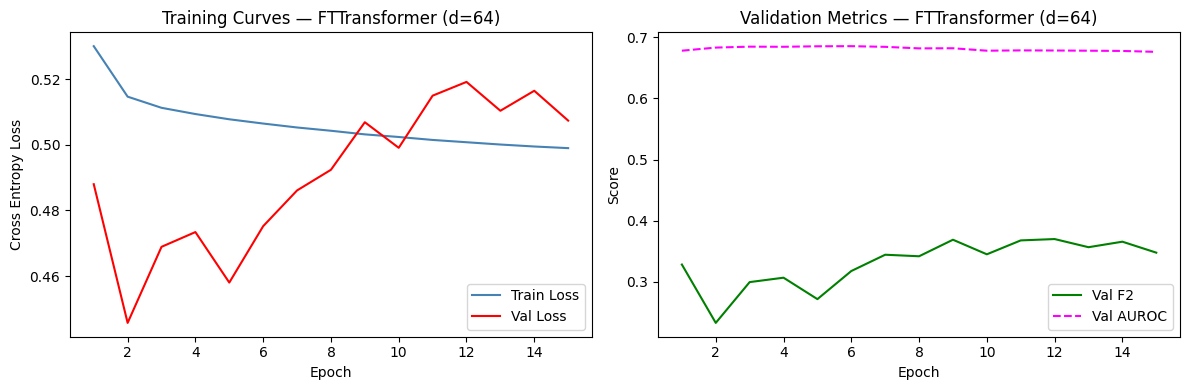

Saved → /dbfs/student-groups/Group_01_02/training_curves.png


In [0]:
import matplotlib.pyplot as plt

epochs   = [h["epoch"]       for h in history_init]
tr_loss  = [h["train_loss"]  for h in history_init]
val_loss = [h["val_loss"]    for h in history_init]
val_f2   = [h["val_fbeta"]   for h in history_init]
val_auc  = [h["val_roc_auc"] for h in history_init]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Training curves
ax1.plot(epochs, tr_loss,  label="Train Loss", color="steelblue")
ax1.plot(epochs, val_loss, label="Val Loss",   color="red")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Cross Entropy Loss")
ax1.set_title(f"Training Curves — FTTransformer (d={CONFIG['d_model']})")
ax1.legend()

# Validation metrics
ax2.plot(epochs, val_f2,  label="Val F2",    color="green")
ax2.plot(epochs, val_auc, label="Val AUROC", color="magenta", linestyle="--")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Score")
ax2.set_title(f"Validation Metrics — FTTransformer (d={CONFIG['d_model']})")
ax2.legend()

plt.tight_layout()
plt.savefig(f"{LOCAL_BASE}/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {LOCAL_BASE}/training_curves.png")

In [0]:
import numpy as np
from sklearn.metrics import (
    f1_score, fbeta_score, average_precision_score, roc_auc_score,
    confusion_matrix, accuracy_score, precision_score, recall_score,
    matthews_corrcoef, balanced_accuracy_score, log_loss,
    precision_recall_curve, roc_curve,
)

# Use results from Section 12 — y_true and y_prob already in memory
# If kernel was restarted, re-run Section 12 evaluate() call first

y_pred_17  = (y_prob >= 0.17).astype(int)   # your tuned threshold
y_pred_50  = (y_prob >= 0.50).astype(int)   # default threshold for comparison

print("=" * 60)
print("COMPREHENSIVE VALIDATION METRICS — TEST SET")
print("=" * 60)

for label, y_pred, thresh in [
    ("Tuned threshold (0.17)", y_pred_17, 0.17),
    ("Default threshold (0.50)", y_pred_50, 0.50),
]:
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    precision  = tp / max(tp + fp, 1)
    recall     = tp / max(tp + fn, 1)
    specificity = tn / max(tn + fp, 1)
    npv        = tn / max(tn + fn, 1)   # negative predictive value
    fpr        = fp / max(fp + tn, 1)   # false positive rate
    fnr        = fn / max(fn + tp, 1)   # false negative rate
    fdr        = fp / max(fp + tp, 1)   # false discovery rate

    f1    = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    fb2   = fbeta_score(y_true, y_pred, beta=2.0, pos_label=1, zero_division=0)
    fb05  = fbeta_score(y_true, y_pred, beta=0.5, pos_label=1, zero_division=0)
    mcc   = matthews_corrcoef(y_true, y_pred)
    acc   = accuracy_score(y_true, y_pred)
    bal   = balanced_accuracy_score(y_true, y_pred)

    print(f"\n── {label} ──")
    print(f"\n  Confusion Matrix:")
    print(f"    TN={tn:>10,}  FP={fp:>10,}")
    print(f"    FN={fn:>10,}  TP={tp:>10,}")

    print(f"\n  Class-level:")
    print(f"    Precision (PPV)       : {precision:.4f}")
    print(f"    Recall (Sensitivity)  : {recall:.4f}")
    print(f"    Specificity (TNR)     : {specificity:.4f}")
    print(f"    Neg Predictive Value  : {npv:.4f}")
    print(f"    False Positive Rate   : {fpr:.4f}")
    print(f"    False Negative Rate   : {fnr:.4f}")
    print(f"    False Discovery Rate  : {fdr:.4f}")

    print(f"\n  Composite metrics:")
    print(f"    F1                    : {f1:.4f}")
    print(f"    F-beta (β=2.0)        : {fb2:.4f}  ← primary metric")
    print(f"    F-beta (β=0.5)        : {fb05:.4f}")
    print(f"    Matthews CC           : {mcc:.4f}")
    print(f"    Accuracy              : {acc:.4f}")
    print(f"    Balanced Accuracy     : {bal:.4f}")

print(f"\n── Threshold-independent ──")
print(f"    ROC-AUC               : {roc_auc_score(y_true, y_prob):.4f}")
print(f"    PR-AUC (Avg Precision): {average_precision_score(y_true, y_prob):.4f}")
print(f"    Log Loss              : {log_loss(y_true, y_prob):.4f}")

# Majority class baseline
majority_acc = max(y_true.mean(), 1 - y_true.mean())
print(f"\n── Baselines ──")
print(f"    Majority class accuracy : {majority_acc:.4f}")
print(f"    Random ROC-AUC          : 0.5000")
print(f"    Delay rate in test set  : {y_true.mean():.4f}")

COMPREHENSIVE VALIDATION METRICS — TEST SET

── Tuned threshold (0.17) ──

  Confusion Matrix:
    TN= 2,167,803  FP= 3,020,729
    FN=   201,821  TP=   850,655

  Class-level:
    Precision (PPV)       : 0.2197
    Recall (Sensitivity)  : 0.8082
    Specificity (TNR)     : 0.4178
    Neg Predictive Value  : 0.9148
    False Positive Rate   : 0.5822
    False Negative Rate   : 0.1918
    False Discovery Rate  : 0.7803

  Composite metrics:
    F1                    : 0.3455
    F-beta (β=2.0)        : 0.5263  ← primary metric
    F-beta (β=0.5)        : 0.2572
    Matthews CC           : 0.1744
    Accuracy              : 0.4836
    Balanced Accuracy     : 0.6130

── Default threshold (0.50) ──

  Confusion Matrix:
    TN= 4,711,476  FP=   477,056
    FN=   790,991  TP=   261,485

  Class-level:
    Precision (PPV)       : 0.3541
    Recall (Sensitivity)  : 0.2484
    Specificity (TNR)     : 0.9081
    Neg Predictive Value  : 0.8562
    False Positive Rate   : 0.0919
    False Negative

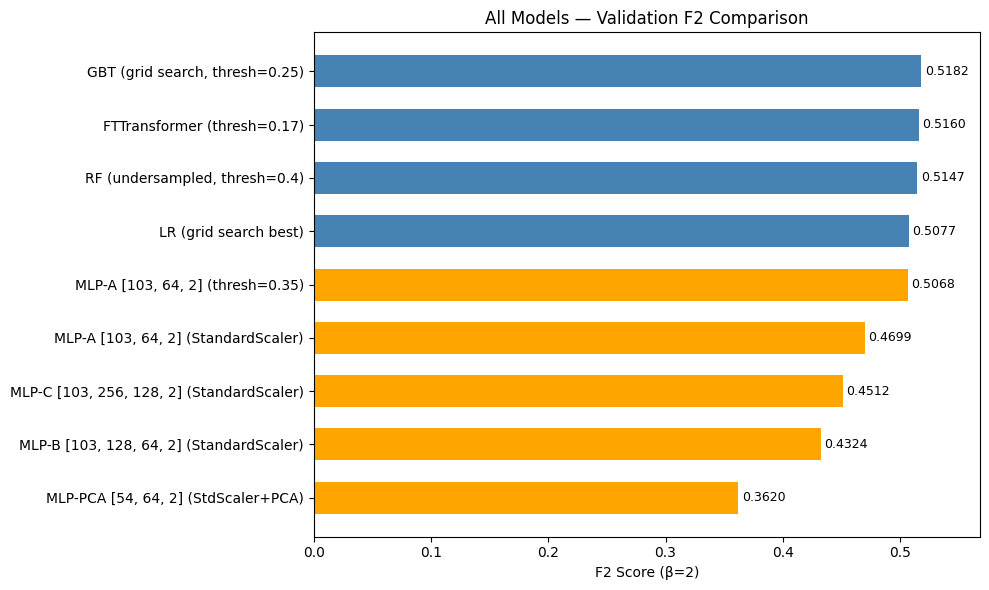

Saved → /dbfs/student-groups/Group_01_02/f2_comparison.png


In [0]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

models = [
    ("GBT (grid search, thresh=0.25)",    0.5182, "steelblue"),
    ("RF (undersampled, thresh=0.4)",     0.5147, "steelblue"),
    ("LR (grid search best)",             0.5077, "steelblue"),
    ("MLP-A [103, 64, 2] (thresh=0.35)", 0.5068, "orange"),
    ("MLP-A [103, 64, 2] (StandardScaler)", 0.4699, "orange"),
    ("MLP-C [103, 256, 128, 2] (StandardScaler)", 0.4512, "orange"),
    ("MLP-B [103, 128, 64, 2] (StandardScaler)", 0.4324, "orange"),
    ("MLP-PCA [54, 64, 2] (StdScaler+PCA)", 0.3620, "orange"),
    ("FTTransformer (thresh=0.17)", 0.5160, "steelblue"),
]

# Sort by score descending
models = sorted(models, key=lambda x: x[1], reverse=True)

names  = [m[0] for m in models]
scores = [m[1] for m in models]
colors = [m[2] for m in models]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(names, scores, color=colors, edgecolor="none", height=0.6)

# Value labels
for bar, score in zip(bars, scores):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f"{score:.4f}", va="center", fontsize=9)

ax.set_xlabel("F2 Score (β=2)")
ax.set_title("All Models — Validation F2 Comparison")
ax.set_xlim(0, max(scores) + 0.05)
ax.invert_yaxis()

# legend_patches = [
#     mpatches.Patch(color="steelblue", label="Traditional ML"),
#     mpatches.Patch(color="orange",    label="MLP / Deep Learning"),
# ]
# ax.legend(handles=legend_patches, loc="lower right")

plt.tight_layout()
plt.savefig(f"{LOCAL_BASE}/f2_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {LOCAL_BASE}/f2_comparison.png")

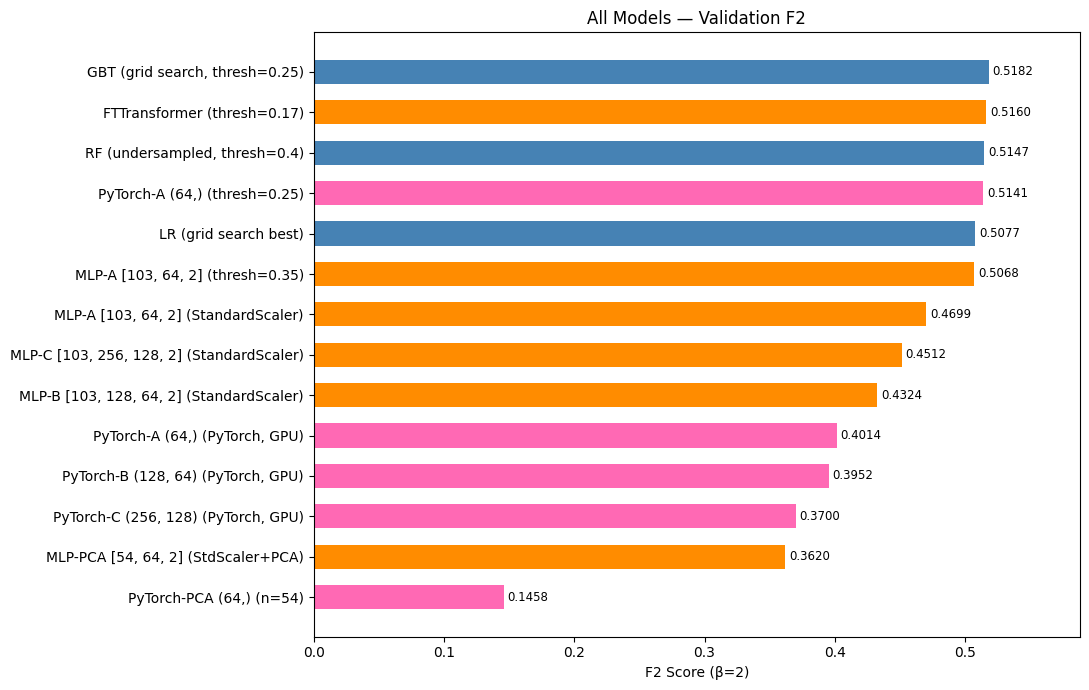

In [0]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

models = [
    # Traditional ML — steelblue
    ("GBT (grid search, thresh=0.25)",            0.5182, "steelblue"),
    ("RF (undersampled, thresh=0.4)",              0.5147, "steelblue"),
    ("LR (grid search best)",                      0.5077, "steelblue"),

    # MLP sklearn — orange
    ("MLP-A [103, 64, 2] (thresh=0.35)",          0.5068, "darkorange"),
    ("MLP-A [103, 64, 2] (StandardScaler)",       0.4699, "darkorange"),
    ("MLP-C [103, 256, 128, 2] (StandardScaler)", 0.4512, "darkorange"),
    ("MLP-B [103, 128, 64, 2] (StandardScaler)",  0.4324, "darkorange"),
    ("MLP-PCA [54, 64, 2] (StdScaler+PCA)",       0.3620, "darkorange"),

    # PyTorch GPU — pink
    ("PyTorch-A (64,) (thresh=0.25)",             0.5141, "hotpink"),
    ("PyTorch-A (64,) (PyTorch, GPU)",            0.4014, "hotpink"),
    ("PyTorch-B (128, 64) (PyTorch, GPU)",        0.3952, "hotpink"),
    ("PyTorch-C (256, 128) (PyTorch, GPU)",       0.3700, "hotpink"),
    ("PyTorch-PCA (64,) (n=54)",                  0.1458, "hotpink"),

    # FTTransformer — steelblue
    ("FTTransformer (thresh=0.17)",               0.5160, "darkorange")
]

# Sort descending
models = sorted(models, key=lambda x: x[1], reverse=True)

names  = [m[0] for m in models]
scores = [m[1] for m in models]
colors = [m[2] for m in models]

fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor("white")

bars = ax.barh(names, scores, color=colors, edgecolor="none", height=0.6)

for bar, score in zip(bars, scores):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f"{score:.4f}", va="center", fontsize=8.5)

ax.set_xlabel("F2 Score (β=2)")
ax.set_title("All Models — Validation F2")
ax.set_xlim(0, max(scores) + 0.07)
ax.invert_yaxis()

# legend_patches = [
#     mpatches.Patch(color="steelblue",  label="Traditional ML"),
#     mpatches.Patch(color="darkorange", label="MLP (sklearn)"),
#     mpatches.Patch(color="hotpink",    label="PyTorch GPU"),
# ]
# ax.legend(handles=legend_patches, loc="lower right", fontsize=9)

plt.tight_layout()
plt.savefig(f"{LOCAL_BASE}/f2_comparison_all.png", dpi=150, bbox_inches="tight")

In [0]:
from sklearn.metrics import (
    fbeta_score, roc_auc_score, recall_score, precision_score
)

# y_true and y_prob must be in memory from Section 12
# If not, re-run the evaluate() call from Section 12 first

BEST_THRESHOLD = 0.17  # from Section 11 — or load from file:
# with open(f"{LOCAL_BASE}/threshold_final.json") as f:
#     BEST_THRESHOLD = json.load(f)["threshold"]

y_pred = (y_prob >= BEST_THRESHOLD).astype(int)

test_f2        = fbeta_score(y_true, y_pred, beta=2.0, pos_label=1, zero_division=0)
test_auroc     = roc_auc_score(y_true, y_prob)
test_recall    = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
test_precision = precision_score(y_true, y_pred, pos_label=1, zero_division=0)

print("Row to add to results table:")
print("-" * 55)
print(f"{'Model':<20} {'Test F2':<10} {'Test AUROC':<12} {'Recall':<10} {'Precision':<12} {'Threshold'}")
print("-" * 55)
print(f"{'FTTransformer':<20} {test_f2:<10.3f} {test_auroc:<12.3f} {test_recall:<10.3f} {test_precision:<12.3f} {BEST_THRESHOLD}")

Row to add to results table:
-------------------------------------------------------
Model                Test F2    Test AUROC   Recall     Precision    Threshold
-------------------------------------------------------
FTTransformer        0.526      0.680        0.808      0.220        0.17
